# Intraday Position - Analytics

## Import Library

In [1]:
import pandas as pd
import numpy as np
import pandas_ta as ta
from utils import load_analytics_dataset, show_3_distribution_charts, show_3_sns_charts

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['figure.dpi'] = 120
import warnings
warnings.filterwarnings('ignore')

## Load Price Data

In [2]:
%%time
dataset = load_analytics_dataset()

CPU times: user 13.7 s, sys: 878 ms, total: 14.5 s
Wall time: 26.6 s


## Charts

In [3]:
data = dataset[(dataset.index > '2020-11-01 00:00:00') & (dataset.index < '2025-05-30 00:00:00')].copy()

In [4]:
data['allow_entry'] = data['allow_entry'].fillna('NaN')

In [5]:
data['allow_entry'].unique()

<ArrowStringArray>
['No - None', 'Yes - Buy', 'No - Sideway', 'NaN', 'Yes - Sell']
Length: 5, dtype: str

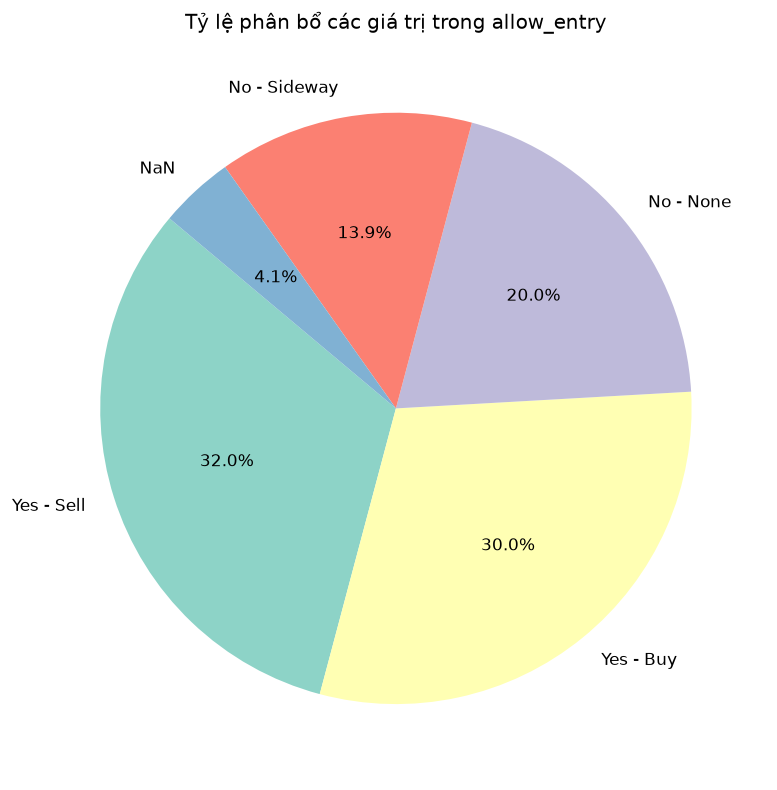

In [6]:
# 1. Đếm số lần xuất hiện của từng giá trị trong intraday_position
counts = data['allow_entry'].value_counts(dropna=False)

# 2. Vẽ biểu đồ tròn
plt.figure(figsize=(8, 8))
plt.pie(
    counts.values, 
    labels=counts.index, 
    autopct='%1.1f%%',  # Hiển thị tỷ lệ phần trăm (1 chữ số thập phân)
    startangle=140,     # Góc xoay biểu đồ
    colors=plt.cm.Set3.colors # Bộ màu hài hòa
)

plt.title('Tỷ lệ phân bổ các giá trị trong allow_entry')
plt.show()

In [10]:
import seaborn as sns

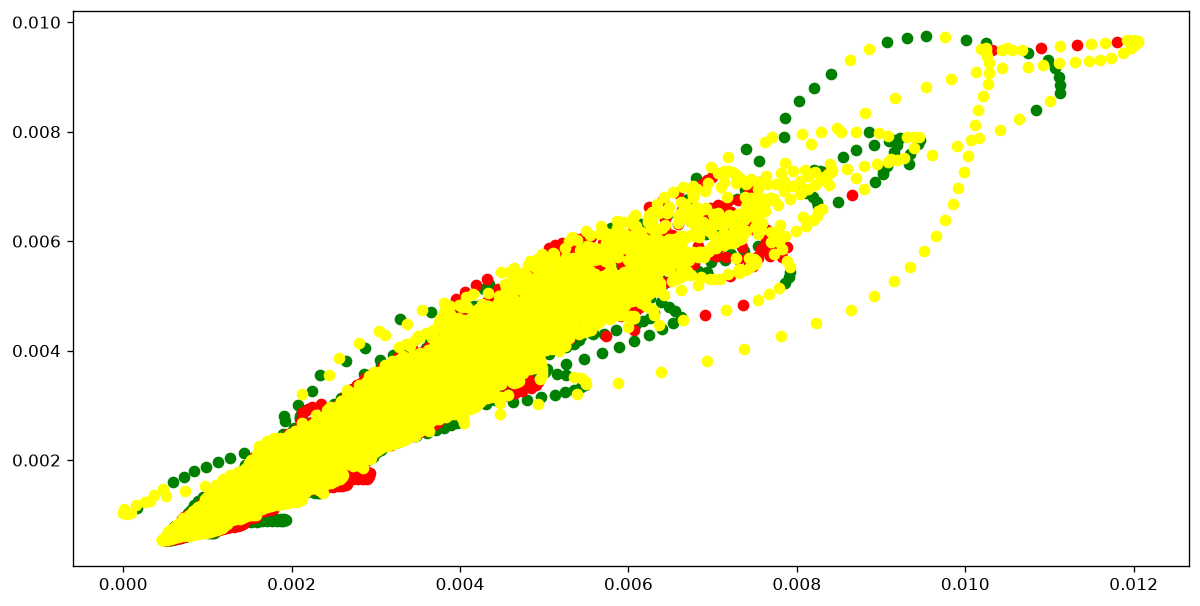

In [8]:
data_buy= data[data['allow_entry'] == "Yes - Buy"]
data_sell = data[data['allow_entry'] == "Yes - Sell"]
data_none = data[(data['allow_entry'] != "Yes - Buy") & (data['allow_entry'] != "Yes - Sell")]
plt.scatter(data_buy['atr_sma20'], data_buy['apz'], c='green')
plt.scatter(data_sell['atr_sma20'], data_sell['apz'], c='red')
plt.scatter(data_none['atr_sma20'], data_none['apz'], c='yellow')

Text(0.5, 1.0, 'Sự ảnh hưởng của close_vs_session_range and dm tới allow_entry')

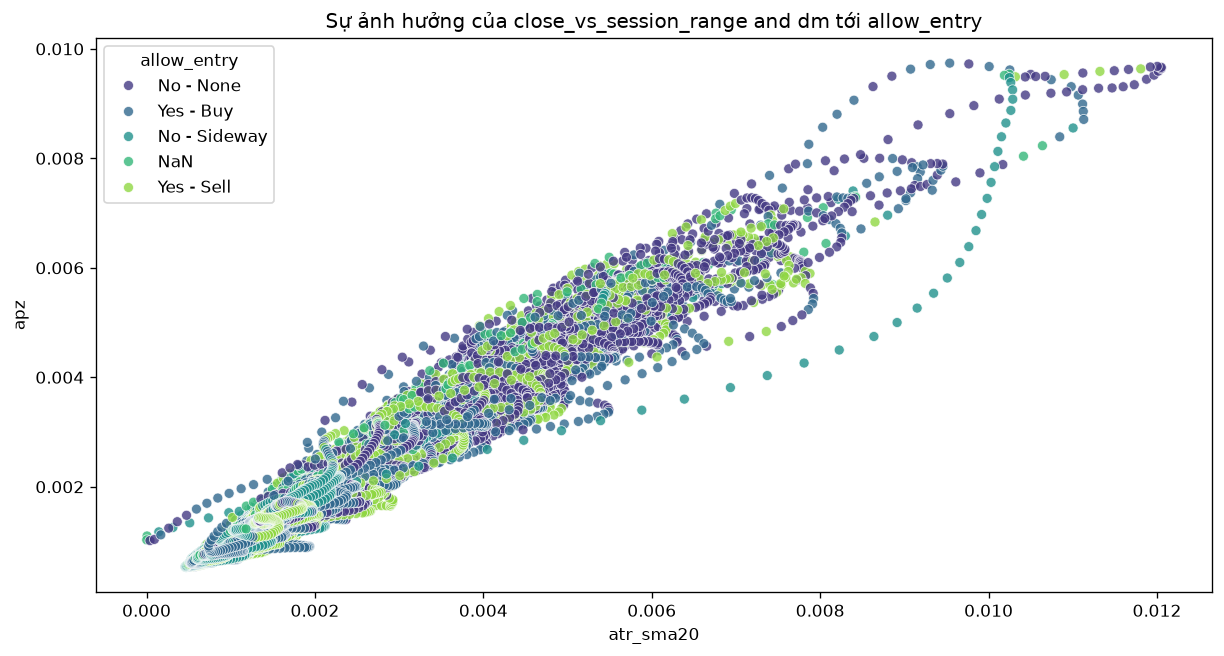

In [11]:
sns.scatterplot(
    data=data[['atr_sma20', 'apz', 'allow_entry']],
    x='atr_sma20',
    y='apz',
    hue='allow_entry',
    palette='viridis',
    alpha=0.8
)
plt.title('Sự ảnh hưởng của close_vs_session_range and dm tới allow_entry')